# **DATA SCIENTIST: BREEZY_360**
#### This project presents a machine learning approach to predicting house prices using a synthetic dataset that simulates real estate conditions in an urban environment, specifically Paris. The dataset consists entirely of numerical variables representing key property characteristics such as size, number of rooms, construction year, number of floors, and ownership history. It also includes features related to amenities like yards, pools, garages, basements, attics, storage rooms, and guest rooms. Location-based attributes, including city codes and neighborhood exclusivity ranges, are incorporated to reflect geographic and socioeconomic differences. Indicators of property condition, such as whether a house is newly built or equipped with storm protection, are also considered. The target variable of the model is the house price, which the system aims to predict accurately. By analyzing the relationships between these features and housing prices, the project demonstrates the practical use of machine learning techniques in real estate valuation and urban data analysis.

In [2]:
#import the required libraries
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.ticker as mtick  
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn import preprocessing
from sklearn.preprocessing import Normalizer,MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, ward
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_samples
from matplotlib import cm
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
#importing the necessary libraries
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor, BaggingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost.sklearn import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

from sklearn import metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


import warnings
warnings.filterwarnings('ignore')

In [3]:
house= pd.read_csv(r"C:\Users\Admin\Desktop\machine learning\HOUSE\ParisHousing.csv")

In [4]:
house.head()

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price
0,75523,3,0,1,63,9373,3,8,2005,0,1,4313,9005,956,0,7,7559081.5
1,80771,39,1,1,98,39381,8,6,2015,1,0,3653,2436,128,1,2,8085989.5
2,55712,58,0,1,19,34457,6,8,2021,0,0,2937,8852,135,1,9,5574642.1
3,32316,47,0,0,6,27939,10,4,2012,0,1,659,7141,359,0,3,3232561.2
4,70429,19,1,1,90,38045,3,7,1990,1,0,8435,2429,292,1,4,7055052.0


In [5]:
year = 2026
house["propertyAge"] = 2026 - house["made"]


In [6]:
house.head()

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price,propertyAge
0,75523,3,0,1,63,9373,3,8,2005,0,1,4313,9005,956,0,7,7559081.5,21
1,80771,39,1,1,98,39381,8,6,2015,1,0,3653,2436,128,1,2,8085989.5,11
2,55712,58,0,1,19,34457,6,8,2021,0,0,2937,8852,135,1,9,5574642.1,5
3,32316,47,0,0,6,27939,10,4,2012,0,1,659,7141,359,0,3,3232561.2,14
4,70429,19,1,1,90,38045,3,7,1990,1,0,8435,2429,292,1,4,7055052.0,36


In [9]:
house.shape

(10000, 18)

In [10]:
house.columns.values

array(['squareMeters', 'numberOfRooms', 'hasYard', 'hasPool', 'floors',
       'cityCode', 'cityPartRange', 'numPrevOwners', 'made', 'isNewBuilt',
       'hasStormProtector', 'basement', 'attic', 'garage',
       'hasStorageRoom', 'hasGuestRoom', 'price', 'propertyAge'],
      dtype=object)

In [9]:
#max_price_row = laptop.loc[laptop["Price_Tsh"].idxmax()]
#max_price_row


In [11]:

# Total missing values and their percentage
total_rows = house.shape[0]

missing_count = house.isnull().sum()
missing_percent = (missing_count / total_rows) * 100
dtypes = house.dtypes

print("#   Column               Dtype           Missing   Missing(%)")
print("-" * 61)

for i, col in enumerate(house.columns):
    print(
        f"{i:<3} "
        f"{col:<22} "
        f"{str(dtypes[col]):<15} "
        f"{missing_count[col]:<9} "
        f"{missing_percent[col]:<12.2f}"
    )
'''
missing_summary = pd.DataFrame({
    "Column": laptop.columns,
    "Dtype": laptop.dtypes.values,
    "Missing": missing_count.values,
    "Missing(%)": missing_percent.values
})

missing_summary
'''


#   Column               Dtype           Missing   Missing(%)
-------------------------------------------------------------
0   squareMeters           int64           0         0.00        
1   numberOfRooms          int64           0         0.00        
2   hasYard                int64           0         0.00        
3   hasPool                int64           0         0.00        
4   floors                 int64           0         0.00        
5   cityCode               int64           0         0.00        
6   cityPartRange          int64           0         0.00        
7   numPrevOwners          int64           0         0.00        
8   made                   int64           0         0.00        
9   isNewBuilt             int64           0         0.00        
10  hasStormProtector      int64           0         0.00        
11  basement               int64           0         0.00        
12  attic                  int64           0         0.00        
13  garage        

'\nmissing_summary = pd.DataFrame({\n    "Column": laptop.columns,\n    "Dtype": laptop.dtypes.values,\n    "Missing": missing_count.values,\n    "Missing(%)": missing_percent.values\n})\n\nmissing_summary\n'

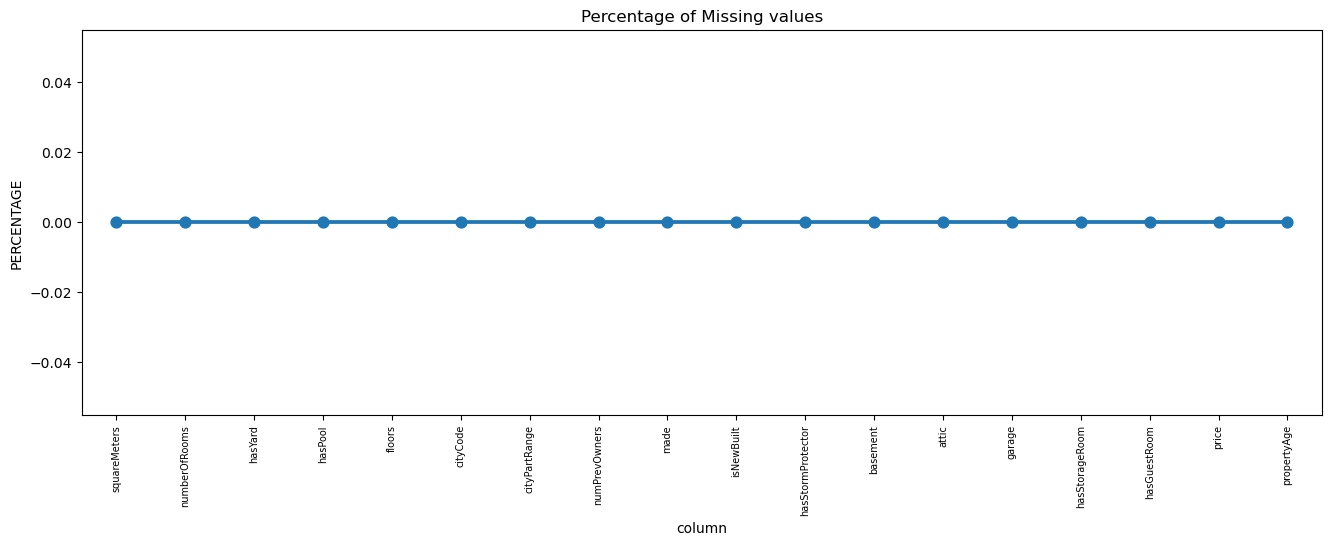

In [12]:
missing = pd.DataFrame({
    'column': house.isnull().sum().index,
    'missing_pct': house.isnull().sum().values * 100 / house.shape[0]
})
plt.figure(figsize=(16,5))
ax = sns.pointplot(x='column', y='missing_pct', data=missing)
plt.xticks(rotation=90, fontsize=7)
plt.title("Percentage of Missing values")
plt.ylabel("PERCENTAGE")
plt.show()

There are no missing value 

In [25]:
#Numerical analysis
house.describe().T#transpose()

,count,mean,std,min,25%,50%,75%,max
squareMeters,10000.0,4.987013e+04,2.877438e+04,89.0,25098.50,50105.5,74609.75,99999.0
numberOfRooms,10000.0,5.035840e+01,2.881670e+01,1.0,25.00,50.0,75.00,100.0
hasYard,10000.0,5.087000e-01,4.999493e-01,0.0,0.00,1.0,1.00,1.0
hasPool,10000.0,4.968000e-01,5.000148e-01,0.0,0.00,0.0,1.00,1.0
floors,10000.0,5.027630e+01,2.888917e+01,1.0,25.00,50.0,76.00,100.0
cityCode,10000.0,5.022549e+04,2.900668e+04,3.0,24693.75,50693.0,75683.25,99953.0
cityPartRange,10000.0,5.510100e+00,2.872024e+00,1.0,3.00,5.0,8.00,10.0
numPrevOwners,10000.0,5.521700e+00,2.856667e+00,1.0,3.00,5.0,8.00,10.0
made,10000.0,2.005488e+03,9.308090e+00,1990.0,1997.00,2005.5,2014.00,2021.0
isNewBuilt,10000.0,4.991000e-01,5.000242e-01,0.0,0.00,0.0,1.00,1.0


The dataset consists of 10,000 housing records with substantial variability across property characteristics, making it suitable for machine learning analysis. On average, houses have large floor areas, around 50 rooms and floors, and are approximately 20 years old, having been built mainly around 2005. Binary features such as yards, pools, storage rooms, storm protection, and new construction are nearly evenly distributed, indicating balanced representation of amenities. Location-related variables show wide geographic and neighborhood diversity, while ownership history suggests moderate turnover. Additional spaces such as basements, attics, and garages vary considerably in size. House prices average around 5 million, with a broad range from low- to high-value properties, reflecting strong price dispersion influenced by structural, locational, and amenity-related factors.

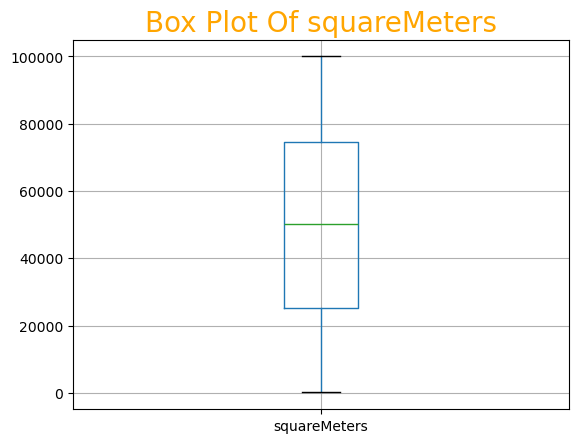

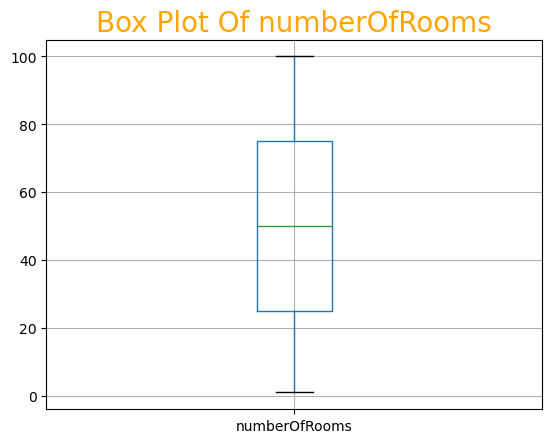

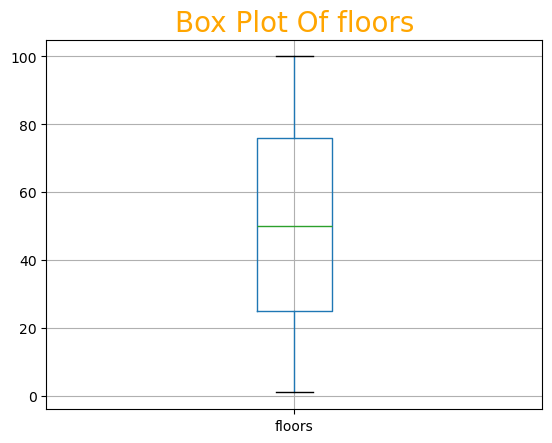

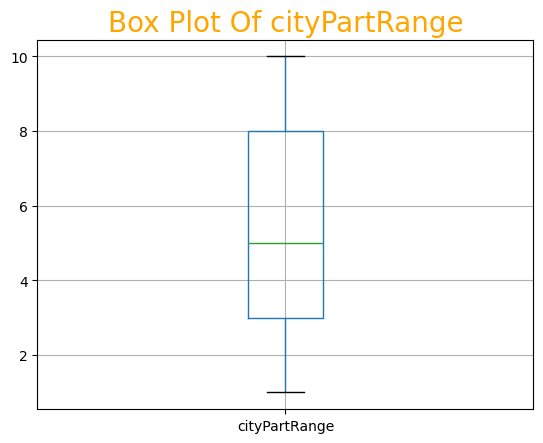

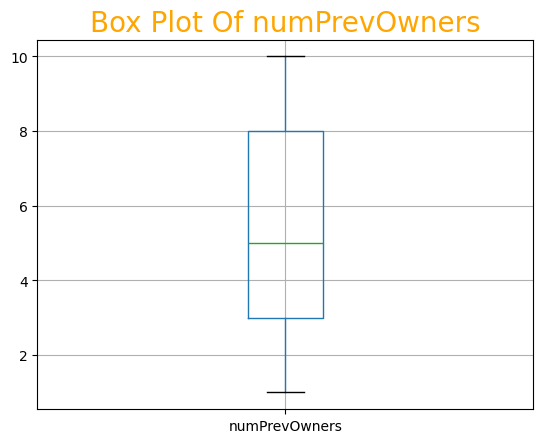

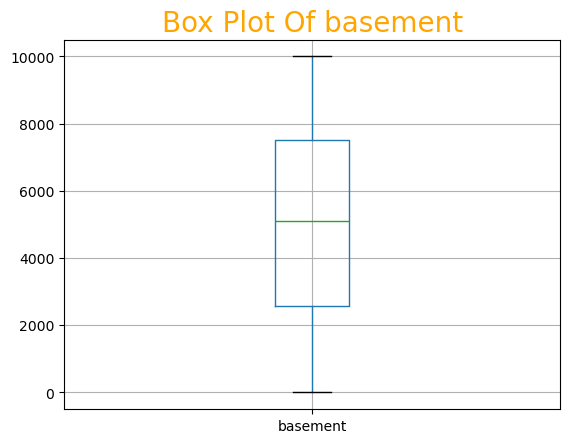

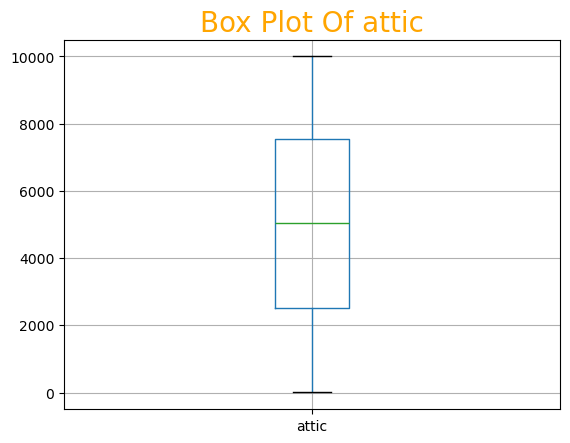

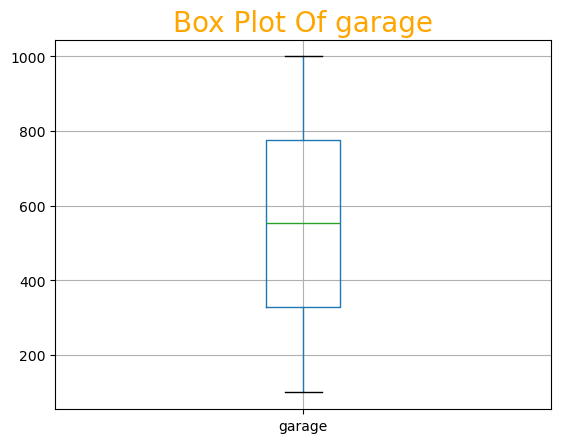

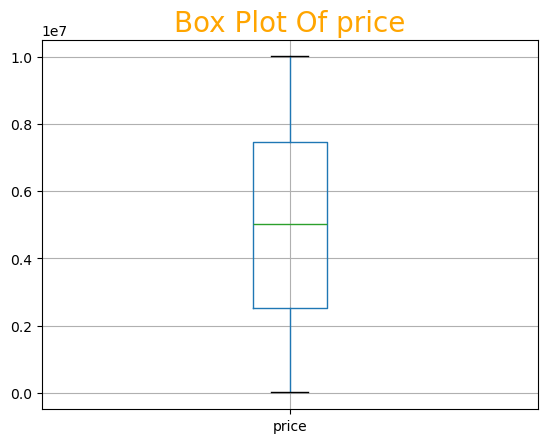

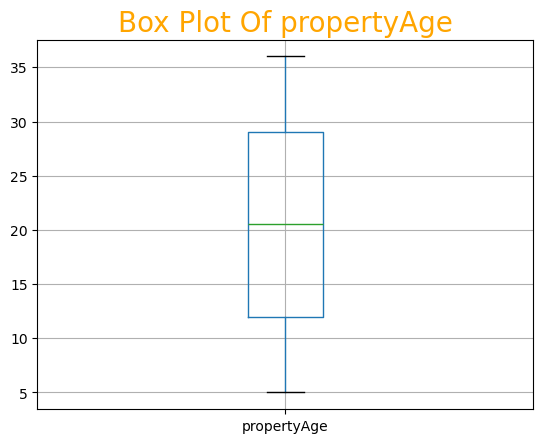

In [17]:
# boxplot all the numerical columns and see if there any outliers
for i in house[['squareMeters', 'numberOfRooms',  'floors',
                    'cityPartRange', 'numPrevOwners',
                    'basement', 'attic', 'garage',
                     'price', 'propertyAge']].columns:
    house.boxplot(column=i)
    plt.title(f"Box Plot Of {i}" , fontsize=20,
          color="orange")
    plt.show()

There are no missing value 

In [23]:
# function for dropping duplicates        
def duplicate(house):
    if house.duplicated().sum()>0:
        print(start+'Dataframe contains duplicate values'+end,house.duplicated().sum())
        house.drop_duplicates(inplace=True,ignore_index=True)
        print('Details of dataframe after droping the Duplicate rows')
        details(house)
    else:
        print("Dataframe doesn't contains dublicate Values")

In [24]:
duplicate(house)

Dataframe doesn't contains dublicate Values


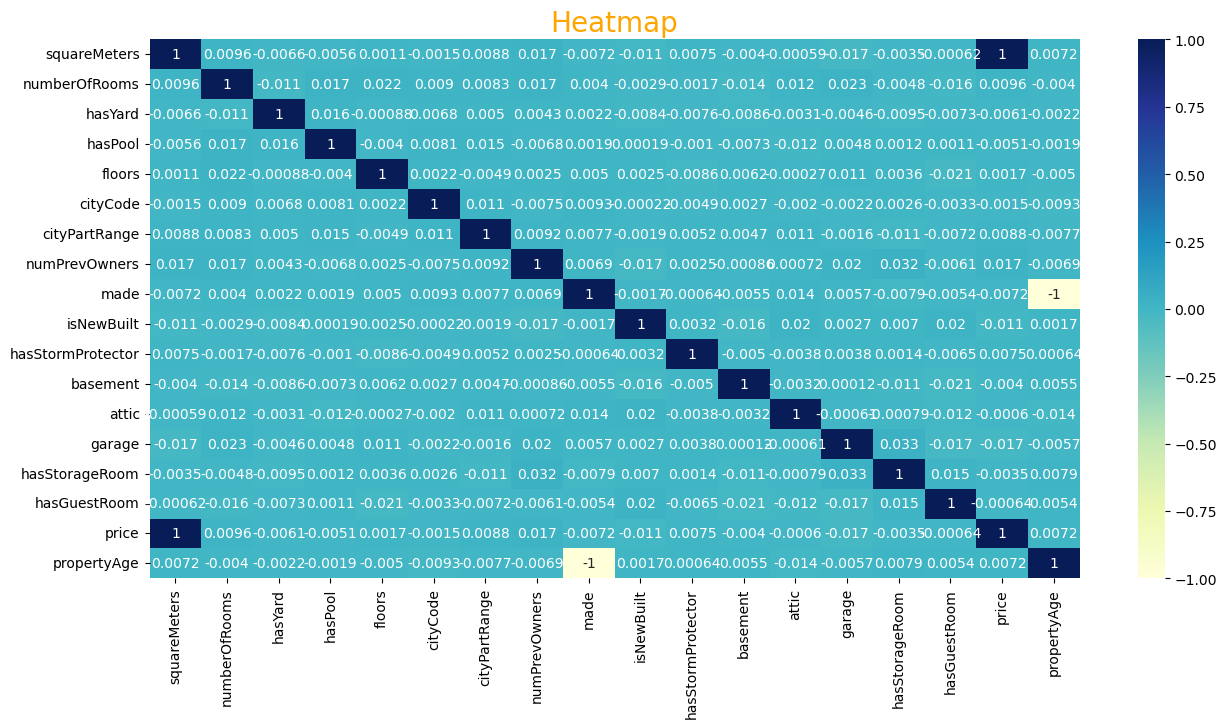

In [18]:
# Plotting heatmap
numeric_tax = house.select_dtypes(include=['int64', 'float64'])
plt.subplots(figsize =(15, 7)) 
sns.heatmap(numeric_tax.corr(),cmap="YlGnBu",annot=True)
plt.title(f"Heatmap" , fontsize=20,color="orange")
plt.show()

In [26]:
# Drop a single column
house = house.drop('made', axis=1)

In [27]:
house.head()

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price,propertyAge
0,75523,3,0,1,63,9373,3,8,0,1,4313,9005,956,0,7,7559081.5,21
1,80771,39,1,1,98,39381,8,6,1,0,3653,2436,128,1,2,8085989.5,11
2,55712,58,0,1,19,34457,6,8,0,0,2937,8852,135,1,9,5574642.1,5
3,32316,47,0,0,6,27939,10,4,0,1,659,7141,359,0,3,3232561.2,14
4,70429,19,1,1,90,38045,3,7,1,0,8435,2429,292,1,4,7055052.0,36


In [28]:
house.columns

Index(['squareMeters', 'numberOfRooms', 'hasYard', 'hasPool', 'floors',
       'cityCode', 'cityPartRange', 'numPrevOwners', 'isNewBuilt',
       'hasStormProtector', 'basement', 'attic', 'garage', 'hasStorageRoom',
       'hasGuestRoom', 'price', 'propertyAge'],
      dtype='object')

In [29]:
house.shape

(10000, 17)

In [35]:
# Divide the data into dependents vs independents
X=house.drop(['price'], axis=1)
y=house['price']

In [36]:
X

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,propertyAge
0,75523,3,0,1,63,9373,3,8,0,1,4313,9005,956,0,7,21
1,80771,39,1,1,98,39381,8,6,1,0,3653,2436,128,1,2,11
2,55712,58,0,1,19,34457,6,8,0,0,2937,8852,135,1,9,5
3,32316,47,0,0,6,27939,10,4,0,1,659,7141,359,0,3,14
4,70429,19,1,1,90,38045,3,7,1,0,8435,2429,292,1,4,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1726,89,0,1,5,73133,7,6,0,1,9311,1698,218,0,4,17
9996,44403,29,1,1,12,34606,9,4,0,1,9061,1742,230,0,0,36
9997,83841,3,0,0,69,80933,10,10,1,1,8304,7730,345,1,9,21
9998,59036,70,0,0,96,55856,1,3,0,1,2590,6174,339,1,4,16


In [37]:
y

0       7559081.5
1       8085989.5
2       5574642.1
3       3232561.2
4       7055052.0
          ...    
9995     176425.9
9996    4448474.0
9997    8390030.5
9998    5905107.0
9999     146708.4
Name: price, Length: 10000, dtype: float64

In [38]:
# Splitting the data into training & test
from sklearn.model_selection import train_test_split
# First split: train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
# Second split: validation + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)
print(f"X_train:{len(X_train)}, X_val:{len(X_val)}, X_test:{len(X_test)}")

X_train:7000, X_val:1500, X_test:1500


In [39]:
print(X_train.shape, y_train.shape)
print(X_test.shape,y_test.shape)
print(X_val.shape, y_val.shape)

(7000, 16) (7000,)
(1500, 16) (1500,)
(1500, 16) (1500,)


In [40]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_val   = sc.transform(X_val)
X_test  = sc.transform(X_test)

In [42]:
# Save the scaler
import pickle 

with open('scaler.sav', 'wb') as f:
    pickle.dump(sc, f)


In [43]:
X_train

array([[-1.55174346,  0.46507434,  0.99231524, ..., -1.00257474,
         1.58611204, -0.47271142],
       [-1.24973439, -1.44332459, -1.00774427, ..., -1.00257474,
         1.58611204,  1.56417768],
       [-1.54992371, -1.65151356, -1.00774427, ..., -1.00257474,
        -0.3044208 , -0.15109735],
       ...,
       [ 1.72563244,  0.60386699,  0.99231524, ...,  0.99743187,
        -0.3044208 ,  1.24256361],
       [-1.13204534, -0.15949258,  0.99231524, ..., -1.00257474,
        -0.93459842,  1.3497683 ],
       [-1.60105178,  1.15903759,  0.99231524, ..., -1.00257474,
         1.58611204,  0.27772141]])

In [44]:
X_test

array([[-0.11427825,  0.70796148,  0.99231524, ...,  0.99743187,
         0.95593443,  0.17051672],
       [-1.25981302, -0.36768156,  0.99231524, ..., -1.00257474,
         0.01066801,  0.59933547],
       [-1.49774578,  0.04869639,  0.99231524, ...,  0.99743187,
        -0.3044208 , -1.11593956],
       ...,
       [ 0.51724618, -0.50647421,  0.99231524, ...,  0.99743187,
        -0.3044208 ,  0.3849261 ],
       [ 0.23878891, -0.29828523,  0.99231524, ..., -1.00257474,
         1.58611204, -1.11593956],
       [-0.90415621, -1.02694664, -1.00774427, ...,  0.99743187,
         1.58611204,  1.3497683 ]])

In [45]:
X_val

array([[-1.52325732, -0.57587053, -1.00774427, ...,  0.99743187,
        -0.61950961, -0.36550673],
       [ 1.27233886,  1.50601921,  0.99231524, ...,  0.99743187,
        -1.56477603, -0.36550673],
       [ 1.59408527,  0.04869639, -1.00774427, ...,  0.99743187,
        -0.61950961, -0.90153018],
       ...,
       [ 0.50496285, -0.74936134, -1.00774427, ...,  0.99743187,
         0.95593443, -1.65196301],
       [-0.87070075,  0.11809272, -1.00774427, ...,  0.99743187,
        -0.61950961,  0.49213078],
       [ 0.52959951, -0.64526685, -1.00774427, ...,  0.99743187,
         0.95593443, -0.47271142]])

# Function for mape and adjusted R2

In [46]:
def mape(y_true, y_pred):
    """
    This function calculates MAPE.
    :param y_true: list of real numbers, true values
    :param y_pred: list of real numbers, predicted values
    :returns: mean absolute percentage error
    """
    return np.mean(np.abs(np.array(y_pred) - np.array(y_true)) / np.array(y_true), axis=0)
def adjR(y_true, y_pred,p):
    R2=r2_score(y_true,y_pred)
    n=10
    return 1-(1-R2)*(n-1)/(n-p-1)

## MODEL BUILDING AND THEIR PERFORMANCE

# Simple Linear Reg Model

In [47]:
# defining the model
LR1 = LinearRegression()
LR1.fit(X_train, y_train)

# Making Predictions
y_LR1_predtr= LR1.predict(X_train)
y_LR1_predvl= LR1.predict(X_val)
y_LR1_predte= LR1.predict(X_test)

LR1.coef_

array([ 2.85752438e+06,  1.63472674e+01,  1.50315361e+03,  1.50020288e+03,
        1.57720833e+03, -2.21894721e+01,  1.51798221e+02,  4.41260418e+00,
        5.86398837e+01,  5.29640873e+01, -1.15443356e+01, -2.00221151e+01,
        2.15092110e+01,  2.21527340e+01, -2.08071299e+01,  3.27568967e+01])

In [49]:
# Performance on train data
LR1_tr_R2score=r2_score(y_train,y_LR1_predtr)
LR1_tr_RMSE=np.sqrt(mean_squared_error(y_train, y_LR1_predtr))
LR1_tr_MSE=mean_squared_error(y_train, y_LR1_predtr)
LR1_tr_MAE=mean_absolute_error(y_train, y_LR1_predtr)
LR1_tr_MAPE=mape(y_train, y_LR1_predtr)
LR1_tr_AR2=adjR(y_train, y_LR1_predtr,p=len(X.columns))

# Performance on val data
LR1_vl_R2score=r2_score(y_val,y_LR1_predvl)
LR1_vl_RMSE=np.sqrt(mean_squared_error(y_val, y_LR1_predvl))
LR1_vl_MSE=mean_squared_error(y_val, y_LR1_predvl)
LR1_vl_MAE=mean_absolute_error(y_val, y_LR1_predvl)
LR1_vl_MAPE=mape(y_val, y_LR1_predvl)
LR1_vl_AR2=adjR(y_val, y_LR1_predvl,p=len(X.columns))

# Performance on test data
LR1_te_R2score=r2_score(y_test,y_LR1_predte)
LR1_te_RMSE=np.sqrt(mean_squared_error(y_test, y_LR1_predte))
LR1_te_MSE=mean_squared_error(y_test, y_LR1_predte)
LR1_te_MAE=mean_absolute_error(y_test, y_LR1_predte)
LR1_te_MAPE=mape(y_test, y_LR1_predte)
LR1_te_AR2=adjR(y_test, y_LR1_predte,p=len(X.columns))

model_comp=pd.DataFrame({'Algorithm':['Simple Linear Reg Model'],
                       'train Score':LR1_tr_R2score,'RMSE_tr': LR1_tr_RMSE, 'MSE_tr': LR1_tr_MSE, 'MAE_tr': LR1_tr_MAE,
                         "Mape_tr":LR1_tr_MAPE, "Adjusted_r2_tr":LR1_tr_AR2,
                        'Val Score':LR1_vl_R2score,'RMSE_vl': LR1_vl_RMSE, 'MSE_vl': LR1_vl_MSE, 'MAE_vl': LR1_vl_MAE,
                         "Mape_val":LR1_vl_MAPE, "Adjusted_r2_val":LR1_vl_AR2,
                      'test Score':LR1_te_R2score,'RMSE_te': LR1_te_RMSE, 'MSE_te': LR1_te_MSE, 'MAE_te': LR1_te_MAE,
                        "Mape_te":LR1_te_MAPE, "Adjusted_r2_te":LR1_te_AR2})
model_comp

,Algorithm,train Score,RMSE_tr,MSE_tr,MAE_tr,Mape_tr,Adjusted_r2_tr,Val Score,RMSE_vl,MSE_vl,MAE_vl,Mape_val,Adjusted_r2_val,test Score,RMSE_te,MSE_te,MAE_te,Mape_te,Adjusted_r2_te
0,Simple Linear Reg Model,1.0,1896.740898,3.597626e+06,1475.955654,0.001025,1.000001,1.0,1923.899522,3.701389e+06,1506.268772,0.000949,1.000001,1.0,1873.320939,3.509331e+06,1464.147307,0.000981,1.000001


# SLinear-Reg (Lasso)

In [50]:
# defining the model
Lasso1 = Lasso(alpha=1)
Lasso1.fit(X_train, y_train)

# Making Predictions
y_Lasso1_predtr= Lasso1.predict(X_train)
y_Lasso1_predvl= Lasso1.predict(X_val)
y_Lasso1_predte= Lasso1.predict(X_test)

Lasso1.coef_

array([ 2.85752275e+06,  1.58387416e+01,  1.50221580e+03,  1.49919883e+03,
        1.57626673e+03, -2.11630844e+01,  1.50852557e+02,  3.52564718e+00,
        5.76861024e+01,  5.20019549e+01, -1.05005193e+01, -1.90135149e+01,
        2.06208487e+01,  2.11441299e+01, -1.98345852e+01,  3.17430901e+01])

In [51]:
# Performance on train data
Lasso1_tr_R2score=r2_score(y_train,y_Lasso1_predtr)
Lasso1_tr_RMSE=np.sqrt(mean_squared_error(y_train, y_Lasso1_predtr))
Lasso1_tr_MSE=mean_squared_error(y_train, y_Lasso1_predtr)
Lasso1_tr_MAE=mean_absolute_error(y_train, y_Lasso1_predtr)
Lasso1_tr_MAPE=mape(y_train, y_Lasso1_predtr)
Lasso1_tr_AR2=adjR(y_train, y_Lasso1_predtr,p=len(X.columns))

# Performance on val data
Lasso1_vl_R2score=r2_score(y_val,y_Lasso1_predvl)
Lasso1_vl_RMSE=np.sqrt(mean_squared_error(y_val, y_Lasso1_predvl))
Lasso1_vl_MSE=mean_squared_error(y_val, y_Lasso1_predvl)
Lasso1_vl_MAE=mean_absolute_error(y_val, y_Lasso1_predvl)
Lasso1_vl_MAPE=mape(y_val, y_Lasso1_predvl)
Lasso1_vl_AR2=adjR(y_val, y_Lasso1_predvl,p=len(X.columns))

# Performance on test data
Lasso1_te_R2score=r2_score(y_test,y_Lasso1_predte)
Lasso1_te_RMSE=np.sqrt(mean_squared_error(y_test, y_Lasso1_predte))
Lasso1_te_MSE=mean_squared_error(y_test, y_Lasso1_predte)
Lasso1_te_MAE=mean_absolute_error(y_test, y_Lasso1_predte)
Lasso1_te_MAPE=mape(y_test, y_Lasso1_predte)
Lasso1_te_AR2=adjR(y_test, y_Lasso1_predte,p=len(X.columns))

Lasso1_df=pd.DataFrame({'Algorithm':['SLinear-Reg (Lasso)'],
                       'train Score':Lasso1_tr_R2score,'RMSE_tr': Lasso1_tr_RMSE, 'MSE_tr': Lasso1_tr_MSE, 'MAE_tr': Lasso1_tr_MAE,
                         "Mape_tr":Lasso1_tr_MAPE, "Adjusted_r2_tr":Lasso1_tr_AR2,
                        'Val Score':Lasso1_vl_R2score,'RMSE_vl': Lasso1_vl_RMSE, 'MSE_vl': Lasso1_vl_MSE, 'MAE_vl': Lasso1_vl_MAE,
                         "Mape_val":Lasso1_vl_MAPE, "Adjusted_r2_val":Lasso1_vl_AR2,
                      'test Score':Lasso1_te_R2score,'RMSE_te': Lasso1_te_RMSE, 'MSE_te': Lasso1_te_MSE, 'MAE_te': Lasso1_te_MAE,
                        "Mape_te":Lasso1_te_MAPE, "Adjusted_r2_te":Lasso1_te_AR2})
model_comp = pd.concat([model_comp, Lasso1_df]).reset_index(drop=True)

model_comp

,Algorithm,train Score,RMSE_tr,MSE_tr,MAE_tr,Mape_tr,Adjusted_r2_tr,Val Score,RMSE_vl,MSE_vl,MAE_vl,Mape_val,Adjusted_r2_val,test Score,RMSE_te,MSE_te,MAE_te,Mape_te,Adjusted_r2_te
0,Simple Linear Reg Model,1.0,1896.740898,3.597626e+06,1475.955654,0.001025,1.000001,1.0,1923.899522,3.701389e+06,1506.268772,0.000949,1.000001,1.0,1873.320939,3.509331e+06,1464.147307,0.000981,1.000001
1,SLinear-Reg (Lasso),1.0,1896.745232,3.597642e+06,1475.906284,0.001025,1.000001,1.0,1923.938051,3.701538e+06,1506.359479,0.000949,1.000001,1.0,1873.231809,3.508997e+06,1463.943186,0.000981,1.000001


# Ridge model

In [52]:
# defining the model
Ridge1 = Ridge(alpha=0.5)
Ridge1.fit(X_train, y_train)

# Making Predictions
y_Ridge1_predtr= Ridge1.predict(X_train)
y_Ridge1_predvl= Ridge1.predict(X_val)
y_Ridge1_predte= Ridge1.predict(X_test)

Ridge1.coef_

array([ 2.85731994e+06,  1.81517312e+01,  1.50424074e+03,  1.49555814e+03,
        1.57672810e+03, -2.32160265e+01,  1.52575852e+02,  9.04719448e+00,
        5.77804453e+01,  5.40440151e+01, -1.11504437e+01, -2.13038070e+01,
        1.81383486e+01,  2.17099137e+01, -2.07204480e+01,  3.52581941e+01])

In [53]:
# Performance on train data
Ridge1_tr_R2score=r2_score(y_train,y_Ridge1_predtr)
Ridge1_tr_RMSE=np.sqrt(mean_squared_error(y_train, y_Ridge1_predtr))
Ridge1_tr_MSE=mean_squared_error(y_train, y_Ridge1_predtr)
Ridge1_tr_MAE=mean_absolute_error(y_train, y_Ridge1_predtr)
Ridge1_tr_MAPE=mape(y_train, y_Ridge1_predtr)
Ridge1_tr_AR2=adjR(y_train, y_Ridge1_predtr,p=len(X.columns))

# Performance on val data
Ridge1_vl_R2score=r2_score(y_val,y_Ridge1_predvl)
Ridge1_vl_RMSE=np.sqrt(mean_squared_error(y_val, y_Ridge1_predvl))
Ridge1_vl_MSE=mean_squared_error(y_val, y_Ridge1_predvl)
Ridge1_vl_MAE=mean_absolute_error(y_val, y_Ridge1_predvl)
Ridge1_vl_MAPE=mape(y_val, y_Ridge1_predvl)
Ridge1_vl_AR2=adjR(y_val, y_Ridge1_predvl,p=len(X.columns))

# Performance on test data
Ridge1_te_R2score=r2_score(y_test,y_Ridge1_predte)
Ridge1_te_RMSE=np.sqrt(mean_squared_error(y_test, y_Ridge1_predte))
Ridge1_te_MSE=mean_squared_error(y_test, y_Ridge1_predte)
Ridge1_te_MAE=mean_absolute_error(y_test, y_Ridge1_predte)
Ridge1_te_MAPE=mape(y_test, y_Ridge1_predte)
Ridge1_te_AR2=adjR(y_test, y_Ridge1_predte,p=len(X.columns))

Ridge1_df=pd.DataFrame({'Algorithm':['SLinear-Reg (Ridge)'],
                       'train Score':Ridge1_tr_R2score,'RMSE_tr': Ridge1_tr_RMSE, 'MSE_tr': Ridge1_tr_MSE, 'MAE_tr': Ridge1_tr_MAE,
                         "Mape_tr":Ridge1_tr_MAPE, "Adjusted_r2_tr":Ridge1_tr_AR2,
                        'Val Score':Ridge1_vl_R2score,'RMSE_vl': Ridge1_vl_RMSE, 'MSE_vl': Ridge1_vl_MSE, 'MAE_vl': Ridge1_vl_MAE,
                         "Mape_val":Ridge1_vl_MAPE, "Adjusted_r2_val":Ridge1_vl_AR2,
                      'test Score':Ridge1_te_R2score,'RMSE_te': Ridge1_te_RMSE, 'MSE_te': Ridge1_te_MSE, 'MAE_te': Ridge1_te_MAE,
                        "Mape_te":Ridge1_te_MAPE, "Adjusted_r2_te":Ridge1_te_AR2})
model_comp = pd.concat([model_comp, Ridge1_df]).reset_index(drop=True)

model_comp

,Algorithm,train Score,RMSE_tr,MSE_tr,MAE_tr,Mape_tr,Adjusted_r2_tr,Val Score,RMSE_vl,MSE_vl,MAE_vl,Mape_val,Adjusted_r2_val,test Score,RMSE_te,MSE_te,MAE_te,Mape_te,Adjusted_r2_te
0,Simple Linear Reg Model,1.0,1896.740898,3.597626e+06,1475.955654,0.001025,1.000001,1.0,1923.899522,3.701389e+06,1506.268772,0.000949,1.000001,1.0,1873.320939,3.509331e+06,1464.147307,0.000981,1.000001
1,SLinear-Reg (Lasso),1.0,1896.745232,3.597642e+06,1475.906284,0.001025,1.000001,1.0,1923.938051,3.701538e+06,1506.359479,0.000949,1.000001,1.0,1873.231809,3.508997e+06,1463.943186,0.000981,1.000001
2,SLinear-Reg (Ridge),1.0,1907.708251,3.639351e+06,1487.192754,0.001072,1.000001,1.0,1937.786348,3.755016e+06,1517.286472,0.000989,1.000001,1.0,1887.039109,3.560917e+06,1479.272732,0.001022,1.000001


# KNN Regressor

In [54]:
# defining the model
knn1 = KNeighborsRegressor(n_neighbors=4,weights='distance')
knn1.fit(X_train, y_train)

# Making Predictions
y_knn1_predtr= knn1.predict(X_train)
y_knn1_predvl= knn1.predict(X_val)
y_knn1_predte= knn1.predict(X_test)

In [55]:
# Performance on train data
knn1_tr_R2score=r2_score(y_train,y_knn1_predtr)
knn1_tr_RMSE=np.sqrt(mean_squared_error(y_train, y_knn1_predtr))
knn1_tr_MSE=mean_squared_error(y_train, y_knn1_predtr)
knn1_tr_MAE=mean_absolute_error(y_train, y_knn1_predtr)
knn1_tr_MAPE=mape(y_train, y_knn1_predtr)
knn1_tr_AR2=adjR(y_train, y_knn1_predtr,p=len(X.columns))

# Performance on val data
knn1_vl_R2score=r2_score(y_val,y_knn1_predvl)
knn1_vl_RMSE=np.sqrt(mean_squared_error(y_val, y_knn1_predvl))
knn1_vl_MSE=mean_squared_error(y_val, y_knn1_predvl)
knn1_vl_MAE=mean_absolute_error(y_val, y_knn1_predvl)
knn1_vl_MAPE=mape(y_val, y_knn1_predvl)
knn1_vl_AR2=adjR(y_val, y_knn1_predvl,p=len(X.columns))

# Performance on test data
knn1_te_R2score=r2_score(y_test,y_knn1_predte)
knn1_te_RMSE=np.sqrt(mean_squared_error(y_test, y_knn1_predte))
knn1_te_MSE=mean_squared_error(y_test, y_knn1_predte)
knn1_te_MAE=mean_absolute_error(y_test, y_knn1_predte)
knn1_te_MAPE=mape(y_test, y_knn1_predte)
knn1_te_AR2=adjR(y_test, y_knn1_predte,p=len(X.columns))

knn1_df=pd.DataFrame({'Algorithm':['KNN'],
                       'train Score':knn1_tr_R2score,'RMSE_tr': knn1_tr_RMSE, 'MSE_tr': knn1_tr_MSE, 'MAE_tr': knn1_tr_MAE,
                         "Mape_tr":knn1_tr_MAPE, "Adjusted_r2_tr":knn1_tr_AR2,
                        'Val Score':knn1_vl_R2score,'RMSE_vl': knn1_vl_RMSE, 'MSE_vl': knn1_vl_MSE, 'MAE_vl': knn1_vl_MAE,
                         "Mape_val":knn1_vl_MAPE, "Adjusted_r2_val":knn1_vl_AR2,
                      'test Score':knn1_te_R2score,'RMSE_te': knn1_te_RMSE, 'MSE_te': knn1_te_MSE, 'MAE_te': knn1_te_MAE,
                        "Mape_te":knn1_te_MAPE, "Adjusted_r2_te":knn1_te_AR2})
model_comp = pd.concat([model_comp, knn1_df]).reset_index(drop=True)

model_comp

,Algorithm,train Score,RMSE_tr,MSE_tr,MAE_tr,Mape_tr,Adjusted_r2_tr,Val Score,RMSE_vl,MSE_vl,MAE_vl,Mape_val,Adjusted_r2_val,test Score,RMSE_te,MSE_te,MAE_te,Mape_te,Adjusted_r2_te
0,Simple Linear Reg Model,1.0,1896.740898,3.597626e+06,1475.955654,1.024777e-03,1.000001,1.000000,1.923900e+03,3.701389e+06,1.506269e+03,0.000949,1.000001,1.000000,1.873321e+03,3.509331e+06,1.464147e+03,0.000981,1.000001
1,SLinear-Reg (Lasso),1.0,1896.745232,3.597642e+06,1475.906284,1.025025e-03,1.000001,1.000000,1.923938e+03,3.701538e+06,1.506359e+03,0.000949,1.000001,1.000000,1.873232e+03,3.508997e+06,1.463943e+03,0.000981,1.000001
2,SLinear-Reg (Ridge),1.0,1907.708251,3.639351e+06,1487.192754,1.071742e-03,1.000001,1.000000,1.937786e+03,3.755016e+06,1.517286e+03,0.000989,1.000001,1.000000,1.887039e+03,3.560917e+06,1.479273e+03,0.001022,1.000001
3,KNN,1.0,0.070344,4.948277e-03,0.028771,3.918754e-08,1.000000,0.785624,1.345838e+06,1.811281e+12,1.087183e+06,1.069281,1.275626,0.776979,1.384676e+06,1.917328e+12,1.139000e+06,1.221382,1.286741


# Support vector regressor

In [56]:
# defining the model
SVR1 = SVR(gamma='auto',C=10.0, epsilon=0.2,kernel='rbf')
SVR1.fit(X_train, y_train)

# Making Predictions
y_SVR1_predtr= SVR1.predict(X_train)
y_SVR1_predvl= SVR1.predict(X_val)
y_SVR1_predte= SVR1.predict(X_test)

In [57]:
# Performance on train data
SVR1_tr_R2score=r2_score(y_train,y_SVR1_predtr)
SVR1_tr_RMSE=np.sqrt(mean_squared_error(y_train, y_SVR1_predtr))
SVR1_tr_MSE=mean_squared_error(y_train, y_SVR1_predtr)
SVR1_tr_MAE=mean_absolute_error(y_train, y_SVR1_predtr)
SVR1_tr_MAPE=mape(y_train, y_SVR1_predtr)
SVR1_tr_AR2=adjR(y_train, y_SVR1_predtr,p=len(X.columns))

# Performance on val data
SVR1_vl_R2score=r2_score(y_val,y_SVR1_predvl)
SVR1_vl_RMSE=np.sqrt(mean_squared_error(y_val, y_SVR1_predvl))
SVR1_vl_MSE=mean_squared_error(y_val, y_SVR1_predvl)
SVR1_vl_MAE=mean_absolute_error(y_val, y_SVR1_predvl)
SVR1_vl_MAPE=mape(y_val, y_SVR1_predvl)
SVR1_vl_AR2=adjR(y_val, y_SVR1_predvl,p=len(X.columns))

# Performance on test data
SVR1_te_R2score=r2_score(y_test,y_SVR1_predte)
SVR1_te_RMSE=np.sqrt(mean_squared_error(y_test, y_SVR1_predte))
SVR1_te_MSE=mean_squared_error(y_test, y_SVR1_predte)
SVR1_te_MAE=mean_absolute_error(y_test, y_SVR1_predte)
SVR1_te_MAPE=mape(y_test, y_SVR1_predte)
SVR1_te_AR2=adjR(y_test, y_SVR1_predte,p=len(X.columns))

SVR1_df=pd.DataFrame({'Algorithm':['SVR with kernel rbf'],
                       'train Score':SVR1_tr_R2score,'RMSE_tr': SVR1_tr_RMSE, 'MSE_tr': SVR1_tr_MSE, 'MAE_tr': SVR1_tr_MAE,
                         "Mape_tr":SVR1_tr_MAPE, "Adjusted_r2_tr":SVR1_tr_AR2,
                        'Val Score':SVR1_vl_R2score,'RMSE_vl': SVR1_vl_RMSE, 'MSE_vl': SVR1_vl_MSE, 'MAE_vl': SVR1_vl_MAE,
                         "Mape_val":SVR1_vl_MAPE, "Adjusted_r2_val":SVR1_vl_AR2,
                      'test Score':SVR1_te_R2score,'RMSE_te': SVR1_te_RMSE, 'MSE_te': SVR1_te_MSE, 'MAE_te': SVR1_te_MAE,
                        "Mape_te":SVR1_te_MAPE, "Adjusted_r2_te":SVR1_te_AR2})
model_comp = pd.concat([model_comp, SVR1_df]).reset_index(drop=True)

model_comp

,Algorithm,train Score,RMSE_tr,MSE_tr,MAE_tr,Mape_tr,Adjusted_r2_tr,Val Score,RMSE_vl,MSE_vl,MAE_vl,Mape_val,Adjusted_r2_val,test Score,RMSE_te,MSE_te,MAE_te,Mape_te,Adjusted_r2_te
0,Simple Linear Reg Model,1.00000,1.896741e+03,3.597626e+06,1.475956e+03,1.024777e-03,1.000001,1.000000,1.923900e+03,3.701389e+06,1.506269e+03,0.000949,1.000001,1.000000,1.873321e+03,3.509331e+06,1.464147e+03,0.000981,1.000001
1,SLinear-Reg (Lasso),1.00000,1.896745e+03,3.597642e+06,1.475906e+03,1.025025e-03,1.000001,1.000000,1.923938e+03,3.701538e+06,1.506359e+03,0.000949,1.000001,1.000000,1.873232e+03,3.508997e+06,1.463943e+03,0.000981,1.000001
2,SLinear-Reg (Ridge),1.00000,1.907708e+03,3.639351e+06,1.487193e+03,1.071742e-03,1.000001,1.000000,1.937786e+03,3.755016e+06,1.517286e+03,0.000989,1.000001,1.000000,1.887039e+03,3.560917e+06,1.479273e+03,0.001022,1.000001
3,KNN,1.00000,7.034399e-02,4.948277e-03,2.877106e-02,3.918754e-08,1.000000,0.785624,1.345838e+06,1.811281e+12,1.087183e+06,1.069281,1.275626,0.776979,1.384676e+06,1.917328e+12,1.139000e+06,1.221382,1.286741
4,SVR with kernel rbf,0.00061,2.856627e+06,8.160320e+12,2.463883e+06,2.867282e+00,2.284930,-0.002928,2.910984e+06,8.473827e+12,2.531673e+06,2.659102,2.289478,0.000267,2.931684e+06,8.594773e+12,2.539629e+06,3.260158,2.285371


# Decision Tree Regressor

In [58]:
# defining the model
DT1 = DecisionTreeRegressor()
DT1.fit(X_train, y_train)

# Making Predictions
y_DT1_predtr= DT1.predict(X_train)
y_DT1_predvl= DT1.predict(X_val)
y_DT1_predte= DT1.predict(X_test)


# Performance on train data
DT1_tr_R2score=r2_score(y_train,y_DT1_predtr)
DT1_tr_RMSE=np.sqrt(mean_squared_error(y_train, y_DT1_predtr))
DT1_tr_MSE=mean_squared_error(y_train, y_DT1_predtr)
DT1_tr_MAE=mean_absolute_error(y_train, y_DT1_predtr)
DT1_tr_MAPE=mape(y_train, y_DT1_predtr)
DT1_tr_AR2=adjR(y_train, y_DT1_predtr,p=len(X.columns))

# Performance on val data
DT1_vl_R2score=r2_score(y_val,y_DT1_predvl)
DT1_vl_RMSE=np.sqrt(mean_squared_error(y_val, y_DT1_predvl))
DT1_vl_MSE=mean_squared_error(y_val, y_DT1_predvl)
DT1_vl_MAE=mean_absolute_error(y_val, y_DT1_predvl)
DT1_vl_MAPE=mape(y_val, y_DT1_predvl)
DT1_vl_AR2=adjR(y_val, y_DT1_predvl,p=len(X.columns))

# Performance on test data
DT1_te_R2score=r2_score(y_test,y_DT1_predte)
DT1_te_RMSE=np.sqrt(mean_squared_error(y_test, y_DT1_predte))
DT1_te_MSE=mean_squared_error(y_test, y_DT1_predte)
DT1_te_MAE=mean_absolute_error(y_test, y_DT1_predte)
DT1_te_MAPE=mape(y_test, y_DT1_predte)
DT1_te_AR2=adjR(y_test, y_DT1_predte,p=len(X.columns))

DT1_df=pd.DataFrame({'Algorithm':['Simple DT'],
                       'train Score':DT1_tr_R2score,'RMSE_tr': DT1_tr_RMSE, 'MSE_tr': DT1_tr_MSE, 'MAE_tr': DT1_tr_MAE,
                         "Mape_tr":DT1_tr_MAPE, "Adjusted_r2_tr":DT1_tr_AR2,
                        'Val Score':DT1_vl_R2score,'RMSE_vl': DT1_vl_RMSE, 'MSE_vl': DT1_vl_MSE, 'MAE_vl': DT1_vl_MAE,
                         "Mape_val":DT1_vl_MAPE, "Adjusted_r2_val":DT1_vl_AR2,
                      'test Score':DT1_te_R2score,'RMSE_te': DT1_te_RMSE, 'MSE_te': DT1_te_MSE, 'MAE_te': DT1_te_MAE,
                        "Mape_te":DT1_te_MAPE, "Adjusted_r2_te":DT1_te_AR2})
model_comp = pd.concat([model_comp, DT1_df]).reset_index(drop=True)

model_comp

,Algorithm,train Score,RMSE_tr,MSE_tr,MAE_tr,Mape_tr,Adjusted_r2_tr,Val Score,RMSE_vl,MSE_vl,MAE_vl,Mape_val,Adjusted_r2_val,test Score,RMSE_te,MSE_te,MAE_te,Mape_te,Adjusted_r2_te
0,Simple Linear Reg Model,1.00000,1.896741e+03,3.597626e+06,1.475956e+03,1.024777e-03,1.000001,1.000000,1.923900e+03,3.701389e+06,1.506269e+03,0.000949,1.000001,1.000000,1.873321e+03,3.509331e+06,1.464147e+03,0.000981,1.000001
1,SLinear-Reg (Lasso),1.00000,1.896745e+03,3.597642e+06,1.475906e+03,1.025025e-03,1.000001,1.000000,1.923938e+03,3.701538e+06,1.506359e+03,0.000949,1.000001,1.000000,1.873232e+03,3.508997e+06,1.463943e+03,0.000981,1.000001
2,SLinear-Reg (Ridge),1.00000,1.907708e+03,3.639351e+06,1.487193e+03,1.071742e-03,1.000001,1.000000,1.937786e+03,3.755016e+06,1.517286e+03,0.000989,1.000001,1.000000,1.887039e+03,3.560917e+06,1.479273e+03,0.001022,1.000001
3,KNN,1.00000,7.034399e-02,4.948277e-03,2.877106e-02,3.918754e-08,1.000000,0.785624,1.345838e+06,1.811281e+12,1.087183e+06,1.069281,1.275626,0.776979,1.384676e+06,1.917328e+12,1.139000e+06,1.221382,1.286741
4,SVR with kernel rbf,0.00061,2.856627e+06,8.160320e+12,2.463883e+06,2.867282e+00,2.284930,-0.002928,2.910984e+06,8.473827e+12,2.531673e+06,2.659102,2.289478,0.000267,2.931684e+06,8.594773e+12,2.539629e+06,3.260158,2.285371
5,Simple DT,1.00000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,0.999996,5.894772e+03,3.474833e+07,4.639951e+03,0.002957,1.000005,0.999996,5.653311e+03,3.195993e+07,4.493463e+03,0.003212,1.000005


## DT-modified parameter

In [59]:
# defining the model
DT2 = DecisionTreeRegressor(max_depth=10,min_samples_leaf=5)
DT2.fit(X_train, y_train)

# Making Predictions
y_DT2_predtr= DT2.predict(X_train)
y_DT2_predvl= DT2.predict(X_val)
y_DT2_predte= DT2.predict(X_test)

# Performance on train data
DT2_tr_R2score=r2_score(y_train,y_DT2_predtr)
DT2_tr_RMSE=np.sqrt(mean_squared_error(y_train, y_DT2_predtr))
DT2_tr_MSE=mean_squared_error(y_train, y_DT2_predtr)
DT2_tr_MAE=mean_absolute_error(y_train, y_DT2_predtr)
DT2_tr_MAPE=mape(y_train, y_DT1_predtr)
DT2_tr_AR2=adjR(y_train, y_DT1_predtr,p=len(X.columns))

# Performance on val data
DT2_vl_R2score=r2_score(y_val,y_DT2_predvl)
DT2_vl_RMSE=np.sqrt(mean_squared_error(y_val, y_DT2_predvl))
DT2_vl_MSE=mean_squared_error(y_val, y_DT2_predvl)
DT2_vl_MAE=mean_absolute_error(y_val, y_DT2_predvl)
DT2_vl_MAPE=mape(y_val, y_DT1_predvl)
DT2_vl_AR2=adjR(y_val, y_DT1_predvl,p=len(X.columns))

# Performance on test data
DT2_te_R2score=r2_score(y_test,y_DT2_predte)
DT2_te_RMSE=np.sqrt(mean_squared_error(y_test, y_DT2_predte))
DT2_te_MSE=mean_squared_error(y_test, y_DT2_predte)
DT2_te_MAE=mean_absolute_error(y_test, y_DT2_predte)
DT2_te_MAPE=mape(y_test, y_DT1_predte)
DT2_te_AR2=adjR(y_test, y_DT1_predte,p=len(X.columns))

DT2_df=pd.DataFrame({'Algorithm':['DT with some modified parameter'],
                     'train Score':DT2_tr_R2score,'RMSE_tr': DT2_tr_RMSE, 'MSE_tr': DT2_tr_MSE, 'MAE_tr': DT2_tr_MAE,
                     "Mape_tr":DT2_tr_MAPE, "Adjusted_r2_tr":DT2_tr_AR2,
                     'Val Score':DT2_vl_R2score,'RMSE_vl': DT2_vl_RMSE, 'MSE_vl': DT2_vl_MSE, 'MAE_vl': DT2_vl_MAE,
                      "Mape_val":DT2_vl_MAPE, "Adjusted_r2_val":DT2_vl_AR2,
                    'test Score':DT2_te_R2score,'RMSE_te': DT2_te_RMSE, 'MSE_te': DT2_te_MSE, 'MAE_te': DT2_te_MAE,
                     "Mape_te":DT2_te_MAPE, "Adjusted_r2_te":DT2_te_AR2})
model_comp = pd.concat([model_comp, DT2_df]).reset_index(drop=True)

model_comp

,Algorithm,train Score,RMSE_tr,MSE_tr,MAE_tr,Mape_tr,Adjusted_r2_tr,Val Score,RMSE_vl,MSE_vl,MAE_vl,Mape_val,Adjusted_r2_val,test Score,RMSE_te,MSE_te,MAE_te,Mape_te,Adjusted_r2_te
0,Simple Linear Reg Model,1.000000,1.896741e+03,3.597626e+06,1.475956e+03,1.024777e-03,1.000001,1.000000,1.923900e+03,3.701389e+06,1.506269e+03,0.000949,1.000001,1.000000,1.873321e+03,3.509331e+06,1.464147e+03,0.000981,1.000001
1,SLinear-Reg (Lasso),1.000000,1.896745e+03,3.597642e+06,1.475906e+03,1.025025e-03,1.000001,1.000000,1.923938e+03,3.701538e+06,1.506359e+03,0.000949,1.000001,1.000000,1.873232e+03,3.508997e+06,1.463943e+03,0.000981,1.000001
2,SLinear-Reg (Ridge),1.000000,1.907708e+03,3.639351e+06,1.487193e+03,1.071742e-03,1.000001,1.000000,1.937786e+03,3.755016e+06,1.517286e+03,0.000989,1.000001,1.000000,1.887039e+03,3.560917e+06,1.479273e+03,0.001022,1.000001
3,KNN,1.000000,7.034399e-02,4.948277e-03,2.877106e-02,3.918754e-08,1.000000,0.785624,1.345838e+06,1.811281e+12,1.087183e+06,1.069281,1.275626,0.776979,1.384676e+06,1.917328e+12,1.139000e+06,1.221382,1.286741
4,SVR with kernel rbf,0.000610,2.856627e+06,8.160320e+12,2.463883e+06,2.867282e+00,2.284930,-0.002928,2.910984e+06,8.473827e+12,2.531673e+06,2.659102,2.289478,0.000267,2.931684e+06,8.594773e+12,2.539629e+06,3.260158,2.285371
5,Simple DT,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,0.999996,5.894772e+03,3.474833e+07,4.639951e+03,0.002957,1.000005,0.999996,5.653311e+03,3.195993e+07,4.493463e+03,0.003212,1.000005
6,DT with some modified parameter,0.999999,3.338676e+03,1.114676e+07,2.677077e+03,0.000000e+00,1.000000,0.999997,5.422812e+03,2.940689e+07,4.265185e+03,0.002957,1.000005,0.999997,5.318044e+03,2.828160e+07,4.240450e+03,0.003212,1.000005


# Ensemble techniques

# Gradient Boosting

In [60]:
# defining the model
GB1=GradientBoostingRegressor(n_estimators = 200, learning_rate = 0.1, random_state=22)
GB1.fit(X_train, y_train)

# Making Predictions
y_GB1_predtr= GB1.predict(X_train)
y_GB1_predvl= GB1.predict(X_val)
y_GB1_predte= GB1.predict(X_test)

# Performance on train data
GB1_tr_R2score=r2_score(y_train,y_GB1_predtr)
GB1_tr_RMSE=np.sqrt(mean_squared_error(y_train, y_GB1_predtr))
GB1_tr_MSE=mean_squared_error(y_train, y_GB1_predtr)
GB1_tr_MAE=mean_absolute_error(y_train, y_GB1_predtr)
GB1_tr_MAPE=mape(y_train, y_GB1_predtr)
GB1_tr_AR2=adjR(y_train, y_GB1_predtr,p=len(X.columns))

# Performance on val data
GB1_vl_R2score=r2_score(y_val,y_GB1_predvl)
GB1_vl_RMSE=np.sqrt(mean_squared_error(y_val, y_GB1_predvl))
GB1_vl_MSE=mean_squared_error(y_val, y_GB1_predvl)
GB1_vl_MAE=mean_absolute_error(y_val, y_GB1_predvl)
GB1_vl_MAPE=mape(y_val, y_GB1_predvl)
GB1_vl_AR2=adjR(y_val, y_GB1_predvl,p=len(X.columns))

# Performance on test data
GB1_te_R2score=r2_score(y_test,y_GB1_predte)
GB1_te_RMSE=np.sqrt(mean_squared_error(y_test, y_GB1_predte))
GB1_te_MSE=mean_squared_error(y_test, y_GB1_predte)
GB1_te_MAE=mean_absolute_error(y_test, y_GB1_predte)
GB1_te_MAPE=mape(y_test, y_GB1_predte)
GB1_te_AR2=adjR(y_test, y_GB1_predte,p=len(X.columns))

GB1_df=pd.DataFrame({'Algorithm':['Gradient Boosting'],
                       'train Score':GB1_tr_R2score,'RMSE_tr': GB1_tr_RMSE, 'MSE_tr': GB1_tr_MSE, 'MAE_tr': GB1_tr_MAE,
                         "Mape_tr":GB1_tr_MAPE, "Adjusted_r2_tr":GB1_tr_AR2,
                        'Val Score':GB1_vl_R2score,'RMSE_vl': GB1_vl_RMSE, 'MSE_vl': GB1_vl_MSE, 'MAE_vl': GB1_vl_MAE,
                         "Mape_val":GB1_vl_MAPE, "Adjusted_r2_val":GB1_vl_AR2,
                      'test Score':GB1_te_R2score,'RMSE_te': GB1_te_RMSE, 'MSE_te': GB1_te_MSE, 'MAE_te': GB1_te_MAE,
                        "Mape_te":GB1_te_MAPE, "Adjusted_r2_te":GB1_te_AR2})
model_comp = pd.concat([model_comp, GB1_df]).reset_index(drop=True)

model_comp

,Algorithm,train Score,RMSE_tr,MSE_tr,MAE_tr,Mape_tr,Adjusted_r2_tr,Val Score,RMSE_vl,MSE_vl,MAE_vl,Mape_val,Adjusted_r2_val,test Score,RMSE_te,MSE_te,MAE_te,Mape_te,Adjusted_r2_te
0,Simple Linear Reg Model,1.000000,1.896741e+03,3.597626e+06,1.475956e+03,1.024777e-03,1.000001,1.000000,1.923900e+03,3.701389e+06,1.506269e+03,0.000949,1.000001,1.000000,1.873321e+03,3.509331e+06,1.464147e+03,0.000981,1.000001
1,SLinear-Reg (Lasso),1.000000,1.896745e+03,3.597642e+06,1.475906e+03,1.025025e-03,1.000001,1.000000,1.923938e+03,3.701538e+06,1.506359e+03,0.000949,1.000001,1.000000,1.873232e+03,3.508997e+06,1.463943e+03,0.000981,1.000001
2,SLinear-Reg (Ridge),1.000000,1.907708e+03,3.639351e+06,1.487193e+03,1.071742e-03,1.000001,1.000000,1.937786e+03,3.755016e+06,1.517286e+03,0.000989,1.000001,1.000000,1.887039e+03,3.560917e+06,1.479273e+03,0.001022,1.000001
3,KNN,1.000000,7.034399e-02,4.948277e-03,2.877106e-02,3.918754e-08,1.000000,0.785624,1.345838e+06,1.811281e+12,1.087183e+06,1.069281,1.275626,0.776979,1.384676e+06,1.917328e+12,1.139000e+06,1.221382,1.286741
4,SVR with kernel rbf,0.000610,2.856627e+06,8.160320e+12,2.463883e+06,2.867282e+00,2.284930,-0.002928,2.910984e+06,8.473827e+12,2.531673e+06,2.659102,2.289478,0.000267,2.931684e+06,8.594773e+12,2.539629e+06,3.260158,2.285371
5,Simple DT,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,0.999996,5.894772e+03,3.474833e+07,4.639951e+03,0.002957,1.000005,0.999996,5.653311e+03,3.195993e+07,4.493463e+03,0.003212,1.000005
6,DT with some modified parameter,0.999999,3.338676e+03,1.114676e+07,2.677077e+03,0.000000e+00,1.000000,0.999997,5.422812e+03,2.940689e+07,4.265185e+03,0.002957,1.000005,0.999997,5.318044e+03,2.828160e+07,4.240450e+03,0.003212,1.000005
7,Gradient Boosting,0.999960,1.796665e+04,3.228004e+08,1.361340e+04,5.878775e-03,1.000051,0.999953,1.988092e+04,3.952512e+08,1.526576e+04,0.006694,1.000060,0.999957,1.932229e+04,3.733510e+08,1.457576e+04,0.007227,1.000056


# Bagging Regressor

In [61]:
# defining the model
BGG1=BaggingRegressor(n_estimators=50, oob_score= True,random_state=14)
BGG1.fit(X_train, y_train)

# Making Predictions
y_BGG1_predtr= BGG1.predict(X_train)
y_BGG1_predvl= BGG1.predict(X_val)
y_BGG1_predte= BGG1.predict(X_test)

# Performance on train data
BGG1_tr_R2score=r2_score(y_train,y_BGG1_predtr)
BGG1_tr_RMSE=np.sqrt(mean_squared_error(y_train, y_BGG1_predtr))
BGG1_tr_MSE=mean_squared_error(y_train, y_BGG1_predtr)
BGG1_tr_MAE=mean_absolute_error(y_train, y_BGG1_predtr)
BGG1_tr_MAPE=mape(y_train, y_BGG1_predtr)
BGG1_tr_AR2=adjR(y_train, y_BGG1_predtr,p=len(X.columns))

# Performance on val data
BGG1_vl_R2score=r2_score(y_val,y_BGG1_predvl)
BGG1_vl_RMSE=np.sqrt(mean_squared_error(y_val, y_BGG1_predvl))
BGG1_vl_MSE=mean_squared_error(y_val, y_BGG1_predvl)
BGG1_vl_MAE=mean_absolute_error(y_val, y_BGG1_predvl)
BGG1_vl_MAPE=mape(y_val, y_BGG1_predvl)
BGG1_vl_AR2=adjR(y_val, y_BGG1_predvl,p=len(X.columns))

# Performance on test data
BGG1_te_R2score=r2_score(y_test,y_BGG1_predte)
BGG1_te_RMSE=np.sqrt(mean_squared_error(y_test, y_BGG1_predte))
BGG1_te_MSE=mean_squared_error(y_test, y_BGG1_predte)
BGG1_te_MAE=mean_absolute_error(y_test, y_BGG1_predte)
BGG1_te_MAPE=mape(y_test, y_BGG1_predte)
BGG1_te_AR2=adjR(y_test, y_BGG1_predte,p=len(X.columns))

BGG1_df=pd.DataFrame({'Algorithm':['Bagging Regressor'],
                       'train Score':BGG1_tr_R2score,'RMSE_tr': BGG1_tr_RMSE, 'MSE_tr': BGG1_tr_MSE, 'MAE_tr': BGG1_tr_MAE,
                         "Mape_tr":BGG1_tr_MAPE, "Adjusted_r2_tr":BGG1_tr_AR2,
                        'Val Score':BGG1_vl_R2score,'RMSE_vl': BGG1_vl_RMSE, 'MSE_vl': BGG1_vl_MSE, 'MAE_vl': BGG1_vl_MAE,
                         "Mape_val":BGG1_vl_MAPE, "Adjusted_r2_val":BGG1_vl_AR2,
                      'test Score':BGG1_te_R2score,'RMSE_te': BGG1_te_RMSE, 'MSE_te': BGG1_te_MSE, 'MAE_te': BGG1_te_MAE,
                        "Mape_te":BGG1_te_MAPE, "Adjusted_r2_te":BGG1_te_AR2})
model_comp = pd.concat([model_comp, BGG1_df]).reset_index(drop=True)

model_comp

,Algorithm,train Score,RMSE_tr,MSE_tr,MAE_tr,Mape_tr,Adjusted_r2_tr,Val Score,RMSE_vl,MSE_vl,MAE_vl,Mape_val,Adjusted_r2_val,test Score,RMSE_te,MSE_te,MAE_te,Mape_te,Adjusted_r2_te
0,Simple Linear Reg Model,1.000000,1.896741e+03,3.597626e+06,1.475956e+03,1.024777e-03,1.000001,1.000000,1.923900e+03,3.701389e+06,1.506269e+03,0.000949,1.000001,1.000000,1.873321e+03,3.509331e+06,1.464147e+03,0.000981,1.000001
1,SLinear-Reg (Lasso),1.000000,1.896745e+03,3.597642e+06,1.475906e+03,1.025025e-03,1.000001,1.000000,1.923938e+03,3.701538e+06,1.506359e+03,0.000949,1.000001,1.000000,1.873232e+03,3.508997e+06,1.463943e+03,0.000981,1.000001
2,SLinear-Reg (Ridge),1.000000,1.907708e+03,3.639351e+06,1.487193e+03,1.071742e-03,1.000001,1.000000,1.937786e+03,3.755016e+06,1.517286e+03,0.000989,1.000001,1.000000,1.887039e+03,3.560917e+06,1.479273e+03,0.001022,1.000001
3,KNN,1.000000,7.034399e-02,4.948277e-03,2.877106e-02,3.918754e-08,1.000000,0.785624,1.345838e+06,1.811281e+12,1.087183e+06,1.069281,1.275626,0.776979,1.384676e+06,1.917328e+12,1.139000e+06,1.221382,1.286741
4,SVR with kernel rbf,0.000610,2.856627e+06,8.160320e+12,2.463883e+06,2.867282e+00,2.284930,-0.002928,2.910984e+06,8.473827e+12,2.531673e+06,2.659102,2.289478,0.000267,2.931684e+06,8.594773e+12,2.539629e+06,3.260158,2.285371
5,Simple DT,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,0.999996,5.894772e+03,3.474833e+07,4.639951e+03,0.002957,1.000005,0.999996,5.653311e+03,3.195993e+07,4.493463e+03,0.003212,1.000005
6,DT with some modified parameter,0.999999,3.338676e+03,1.114676e+07,2.677077e+03,0.000000e+00,1.000000,0.999997,5.422812e+03,2.940689e+07,4.265185e+03,0.002957,1.000005,0.999997,5.318044e+03,2.828160e+07,4.240450e+03,0.003212,1.000005
7,Gradient Boosting,0.999960,1.796665e+04,3.228004e+08,1.361340e+04,5.878775e-03,1.000051,0.999953,1.988092e+04,3.952512e+08,1.526576e+04,0.006694,1.000060,0.999957,1.932229e+04,3.733510e+08,1.457576e+04,0.007227,1.000056
8,Bagging Regressor,1.000000,1.538421e+03,2.366740e+06,1.211672e+03,8.762161e-04,1.000000,0.999998,4.091127e+03,1.673732e+07,3.253124e+03,0.002154,1.000003,0.999998,4.014324e+03,1.611479e+07,3.197127e+03,0.002804,1.000002


# Random Forest

In [62]:
# defining the model
RF1=RandomForestRegressor()
RF1.fit(X_train, y_train)

# Making Predictions
y_RF1_predtr= RF1.predict(X_train)
y_RF1_predvl= RF1.predict(X_val)
y_RF1_predte= RF1.predict(X_test)

# Performance on train data
RF1_tr_R2score=r2_score(y_train,y_RF1_predtr)
RF1_tr_RMSE=np.sqrt(mean_squared_error(y_train, y_RF1_predtr))
RF1_tr_MSE=mean_squared_error(y_train, y_RF1_predtr)
RF1_tr_MAE=mean_absolute_error(y_train, y_RF1_predtr)
RF1_tr_MAPE=mape(y_train, y_RF1_predtr)
RF1_tr_AR2=adjR(y_train, y_RF1_predtr,p=len(X.columns))

# Performance on val data
RF1_vl_R2score=r2_score(y_val,y_RF1_predvl)
RF1_vl_RMSE=np.sqrt(mean_squared_error(y_val, y_RF1_predvl))
RF1_vl_MSE=mean_squared_error(y_val, y_RF1_predvl)
RF1_vl_MAE=mean_absolute_error(y_val, y_RF1_predvl)
RF1_vl_MAPE=mape(y_val, y_RF1_predvl)
RF1_vl_AR2=adjR(y_val, y_RF1_predvl,p=len(X.columns))

# Performance on test data
RF1_te_R2score=r2_score(y_test,y_RF1_predte)
RF1_te_RMSE=np.sqrt(mean_squared_error(y_test, y_RF1_predte))
RF1_te_MSE=mean_squared_error(y_test, y_RF1_predte)
RF1_te_MAE=mean_absolute_error(y_test, y_RF1_predte)
RF1_te_MAPE=mape(y_test, y_RF1_predte)
RF1_te_AR2=adjR(y_test, y_RF1_predte,p=len(X.columns))

RF1_df=pd.DataFrame({'Algorithm':['Random Forest'],
                       'train Score':RF1_tr_R2score,'RMSE_tr': RF1_tr_RMSE, 'MSE_tr': RF1_tr_MSE, 'MAE_tr': RF1_tr_MAE,
                         "Mape_tr":RF1_tr_MAPE, "Adjusted_r2_tr":RF1_tr_AR2,
                        'Val Score':RF1_vl_R2score,'RMSE_vl': RF1_vl_RMSE, 'MSE_vl': RF1_vl_MSE, 'MAE_vl': RF1_vl_MAE,
                         "Mape_val":RF1_vl_MAPE, "Adjusted_r2_val":RF1_vl_AR2,
                      'test Score':RF1_te_R2score,'RMSE_te': RF1_te_RMSE, 'MSE_te': RF1_te_MSE, 'MAE_te': RF1_te_MAE,
                        "Mape_te":RF1_te_MAPE, "Adjusted_r2_te":RF1_te_AR2})
model_comp = pd.concat([model_comp, RF1_df]).reset_index(drop=True)

model_comp

,Algorithm,train Score,RMSE_tr,MSE_tr,MAE_tr,Mape_tr,Adjusted_r2_tr,Val Score,RMSE_vl,MSE_vl,MAE_vl,Mape_val,Adjusted_r2_val,test Score,RMSE_te,MSE_te,MAE_te,Mape_te,Adjusted_r2_te
0,Simple Linear Reg Model,1.000000,1.896741e+03,3.597626e+06,1.475956e+03,1.024777e-03,1.000001,1.000000,1.923900e+03,3.701389e+06,1.506269e+03,0.000949,1.000001,1.000000,1.873321e+03,3.509331e+06,1.464147e+03,0.000981,1.000001
1,SLinear-Reg (Lasso),1.000000,1.896745e+03,3.597642e+06,1.475906e+03,1.025025e-03,1.000001,1.000000,1.923938e+03,3.701538e+06,1.506359e+03,0.000949,1.000001,1.000000,1.873232e+03,3.508997e+06,1.463943e+03,0.000981,1.000001
2,SLinear-Reg (Ridge),1.000000,1.907708e+03,3.639351e+06,1.487193e+03,1.071742e-03,1.000001,1.000000,1.937786e+03,3.755016e+06,1.517286e+03,0.000989,1.000001,1.000000,1.887039e+03,3.560917e+06,1.479273e+03,0.001022,1.000001
3,KNN,1.000000,7.034399e-02,4.948277e-03,2.877106e-02,3.918754e-08,1.000000,0.785624,1.345838e+06,1.811281e+12,1.087183e+06,1.069281,1.275626,0.776979,1.384676e+06,1.917328e+12,1.139000e+06,1.221382,1.286741
4,SVR with kernel rbf,0.000610,2.856627e+06,8.160320e+12,2.463883e+06,2.867282e+00,2.284930,-0.002928,2.910984e+06,8.473827e+12,2.531673e+06,2.659102,2.289478,0.000267,2.931684e+06,8.594773e+12,2.539629e+06,3.260158,2.285371
5,Simple DT,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,0.999996,5.894772e+03,3.474833e+07,4.639951e+03,0.002957,1.000005,0.999996,5.653311e+03,3.195993e+07,4.493463e+03,0.003212,1.000005
6,DT with some modified parameter,0.999999,3.338676e+03,1.114676e+07,2.677077e+03,0.000000e+00,1.000000,0.999997,5.422812e+03,2.940689e+07,4.265185e+03,0.002957,1.000005,0.999997,5.318044e+03,2.828160e+07,4.240450e+03,0.003212,1.000005
7,Gradient Boosting,0.999960,1.796665e+04,3.228004e+08,1.361340e+04,5.878775e-03,1.000051,0.999953,1.988092e+04,3.952512e+08,1.526576e+04,0.006694,1.000060,0.999957,1.932229e+04,3.733510e+08,1.457576e+04,0.007227,1.000056
8,Bagging Regressor,1.000000,1.538421e+03,2.366740e+06,1.211672e+03,8.762161e-04,1.000000,0.999998,4.091127e+03,1.673732e+07,3.253124e+03,0.002154,1.000003,0.999998,4.014324e+03,1.611479e+07,3.197127e+03,0.002804,1.000002
9,Random Forest,1.000000,1.479764e+03,2.189703e+06,1.177240e+03,8.679651e-04,1.000000,0.999998,4.110626e+03,1.689724e+07,3.261537e+03,0.002249,1.000003,0.999998,4.007051e+03,1.605646e+07,3.167688e+03,0.002643,1.000002


## Random selection of feature

In [63]:
'''
#feature importance
rf_imp_feature_1=pd.DataFrame(RF1.feature_importances_, columns = ["Imp"], index = X_val.columns)
rf_imp_feature_1.sort_values(by="Imp",ascending=False)
rf_imp_feature_1['Imp'] = rf_imp_feature_1['Imp'].map('{0:.5f}'.format)
rf_imp_feature_1=rf_imp_feature_1.sort_values(by="Imp",ascending=False)
rf_imp_feature_1.Imp=rf_imp_feature_1.Imp.astype("float")

rf_imp_feature_1[:30].plot.bar(figsize=(12,6))

#First 20 features have an importance of 90.5% and first 30 have importance of 95.15
print("First 20 feature importance:\t",(rf_imp_feature_1[:8].sum())*100)
print("First 30 feature importance:\t",(rf_imp_feature_1[:1].sum())*100)'''

'\n#feature importance\nrf_imp_feature_1=pd.DataFrame(RF1.feature_importances_, columns = ["Imp"], index = X_val.columns)\nrf_imp_feature_1.sort_values(by="Imp",ascending=False)\nrf_imp_feature_1[\'Imp\'] = rf_imp_feature_1[\'Imp\'].map(\'{0:.5f}\'.format)\nrf_imp_feature_1=rf_imp_feature_1.sort_values(by="Imp",ascending=False)\nrf_imp_feature_1.Imp=rf_imp_feature_1.Imp.astype("float")\n\nrf_imp_feature_1[:30].plot.bar(figsize=(12,6))\n\n#First 20 features have an importance of 90.5% and first 30 have importance of 95.15\nprint("First 20 feature importance:\t",(rf_imp_feature_1[:8].sum())*100)\nprint("First 30 feature importance:\t",(rf_imp_feature_1[:1].sum())*100)'

# ADA Boost

In [64]:
# defining the model
ADAB=AdaBoostRegressor(DecisionTreeRegressor(random_state=8))
ADAB.fit(X_train, y_train)

# Making Predictions
y_ADAB_predtr= ADAB.predict(X_train)
y_ADAB_predvl= ADAB.predict(X_val)
y_ADAB_predte= ADAB.predict(X_test)

# Performance on train data
ADAB_tr_R2score=r2_score(y_train,y_ADAB_predtr)
ADAB_tr_RMSE=np.sqrt(mean_squared_error(y_train, y_ADAB_predtr))
ADAB_tr_MSE=mean_squared_error(y_train, y_ADAB_predtr)
ADAB_tr_MAE=mean_absolute_error(y_train, y_ADAB_predtr)
ADAB_tr_MAPE=mape(y_train, y_ADAB_predtr)
ADAB_tr_AR2=adjR(y_train, y_ADAB_predtr,p=len(X.columns))

# Performance on val data
ADAB_vl_R2score=r2_score(y_val,y_ADAB_predvl)
ADAB_vl_RMSE=np.sqrt(mean_squared_error(y_val, y_ADAB_predvl))
ADAB_vl_MSE=mean_squared_error(y_val, y_ADAB_predvl)
ADAB_vl_MAE=mean_absolute_error(y_val, y_ADAB_predvl)
ADAB_vl_MAPE=mape(y_val, y_ADAB_predvl)
ADAB_vl_AR2=adjR(y_val, y_ADAB_predvl,p=len(X.columns))

# Performance on test data
ADAB_te_R2score=r2_score(y_test,y_ADAB_predte)
ADAB_te_RMSE=np.sqrt(mean_squared_error(y_test, y_ADAB_predte))
ADAB_te_MSE=mean_squared_error(y_test, y_ADAB_predte)
ADAB_te_MAE=mean_absolute_error(y_test, y_ADAB_predte)
ADAB_te_MAPE=mape(y_test, y_ADAB_predte)
ADAB_te_AR2=adjR(y_test, y_ADAB_predte,p=len(X.columns))

ADAB_df=pd.DataFrame({'Algorithm':['ADA Boost'],
                       'train Score':ADAB_tr_R2score,'RMSE_tr': ADAB_tr_RMSE, 'MSE_tr': ADAB_tr_MSE, 'MAE_tr': ADAB_tr_MAE,
                         "Mape_tr":ADAB_tr_MAPE, "Adjusted_r2_tr":ADAB_tr_AR2,
                        'Val Score':ADAB_vl_R2score,'RMSE_vl': ADAB_vl_RMSE, 'MSE_vl': ADAB_vl_MSE, 'MAE_vl': ADAB_vl_MAE,
                         "Mape_val":ADAB_vl_MAPE, "Adjusted_r2_val":ADAB_vl_AR2,
                      'test Score':ADAB_te_R2score,'RMSE_te': ADAB_te_RMSE, 'MSE_te': ADAB_te_MSE, 'MAE_te': ADAB_te_MAE,
                        "Mape_te":ADAB_te_MAPE, "Adjusted_r2_te":ADAB_te_AR2})
model_comp = pd.concat([model_comp, ADAB_df]).reset_index(drop=True)

model_comp

,Algorithm,train Score,RMSE_tr,MSE_tr,MAE_tr,Mape_tr,Adjusted_r2_tr,Val Score,RMSE_vl,MSE_vl,MAE_vl,Mape_val,Adjusted_r2_val,test Score,RMSE_te,MSE_te,MAE_te,Mape_te,Adjusted_r2_te
0,Simple Linear Reg Model,1.000000,1.896741e+03,3.597626e+06,1.475956e+03,1.024777e-03,1.000001,1.000000,1.923900e+03,3.701389e+06,1.506269e+03,0.000949,1.000001,1.000000,1.873321e+03,3.509331e+06,1.464147e+03,0.000981,1.000001
1,SLinear-Reg (Lasso),1.000000,1.896745e+03,3.597642e+06,1.475906e+03,1.025025e-03,1.000001,1.000000,1.923938e+03,3.701538e+06,1.506359e+03,0.000949,1.000001,1.000000,1.873232e+03,3.508997e+06,1.463943e+03,0.000981,1.000001
2,SLinear-Reg (Ridge),1.000000,1.907708e+03,3.639351e+06,1.487193e+03,1.071742e-03,1.000001,1.000000,1.937786e+03,3.755016e+06,1.517286e+03,0.000989,1.000001,1.000000,1.887039e+03,3.560917e+06,1.479273e+03,0.001022,1.000001
3,KNN,1.000000,7.034399e-02,4.948277e-03,2.877106e-02,3.918754e-08,1.000000,0.785624,1.345838e+06,1.811281e+12,1.087183e+06,1.069281,1.275626,0.776979,1.384676e+06,1.917328e+12,1.139000e+06,1.221382,1.286741
4,SVR with kernel rbf,0.000610,2.856627e+06,8.160320e+12,2.463883e+06,2.867282e+00,2.284930,-0.002928,2.910984e+06,8.473827e+12,2.531673e+06,2.659102,2.289478,0.000267,2.931684e+06,8.594773e+12,2.539629e+06,3.260158,2.285371
5,Simple DT,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,0.999996,5.894772e+03,3.474833e+07,4.639951e+03,0.002957,1.000005,0.999996,5.653311e+03,3.195993e+07,4.493463e+03,0.003212,1.000005
6,DT with some modified parameter,0.999999,3.338676e+03,1.114676e+07,2.677077e+03,0.000000e+00,1.000000,0.999997,5.422812e+03,2.940689e+07,4.265185e+03,0.002957,1.000005,0.999997,5.318044e+03,2.828160e+07,4.240450e+03,0.003212,1.000005
7,Gradient Boosting,0.999960,1.796665e+04,3.228004e+08,1.361340e+04,5.878775e-03,1.000051,0.999953,1.988092e+04,3.952512e+08,1.526576e+04,0.006694,1.000060,0.999957,1.932229e+04,3.733510e+08,1.457576e+04,0.007227,1.000056
8,Bagging Regressor,1.000000,1.538421e+03,2.366740e+06,1.211672e+03,8.762161e-04,1.000000,0.999998,4.091127e+03,1.673732e+07,3.253124e+03,0.002154,1.000003,0.999998,4.014324e+03,1.611479e+07,3.197127e+03,0.002804,1.000002
9,Random Forest,1.000000,1.479764e+03,2.189703e+06,1.177240e+03,8.679651e-04,1.000000,0.999998,4.110626e+03,1.689724e+07,3.261537e+03,0.002249,1.000003,0.999998,4.007051e+03,1.605646e+07,3.167688e+03,0.002643,1.000002


# XGBoost

In [65]:
# defining the model
XGB=XGBRegressor(n_estimators=150,max_depth=5,random_state=7)
XGB.fit(X_train, y_train)

# Making Predictions
y_XGB_predtr= XGB.predict(X_train)
y_XGB_predvl= XGB.predict(X_val)
y_XGB_predte= XGB.predict(X_test)

# Performance on train data
XGB_tr_R2score=r2_score(y_train,y_XGB_predtr)
XGB_tr_RMSE=np.sqrt(mean_squared_error(y_train, y_XGB_predtr))
XGB_tr_MSE=mean_squared_error(y_train, y_XGB_predtr)
XGB_tr_MAE=mean_absolute_error(y_train, y_XGB_predtr)
XGB_tr_MAPE=mape(y_train, y_XGB_predtr)
XGB_tr_AR2=adjR(y_train, y_XGB_predtr,p=len(X.columns))

# Performance on val data
XGB_vl_R2score=r2_score(y_val,y_XGB_predvl)
XGB_vl_RMSE=np.sqrt(mean_squared_error(y_val, y_XGB_predvl))
XGB_vl_MSE=mean_squared_error(y_val, y_XGB_predvl)
XGB_vl_MAE=mean_absolute_error(y_val, y_XGB_predvl)
XGB_vl_MAPE=mape(y_val, y_XGB_predvl)
XGB_vl_AR2=adjR(y_val, y_XGB_predvl,p=len(X.columns))

# Performance on test data
XGB_te_R2score=r2_score(y_test,y_XGB_predte)
XGB_te_RMSE=np.sqrt(mean_squared_error(y_test, y_XGB_predte))
XGB_te_MSE=mean_squared_error(y_test, y_XGB_predte)
XGB_te_MAE=mean_absolute_error(y_test, y_XGB_predte)
XGB_te_MAPE=mape(y_test, y_XGB_predte)
XGB_te_AR2=adjR(y_test, y_XGB_predte,p=len(X.columns))

XGB_df=pd.DataFrame({'Algorithm':['XGBoost'],
                       'train Score':XGB_tr_R2score,'RMSE_tr': XGB_tr_RMSE, 'MSE_tr': XGB_tr_MSE, 'MAE_tr': XGB_tr_MAE,
                         "Mape_tr":XGB_tr_MAPE, "Adjusted_r2_tr":XGB_tr_AR2,
                        'Val Score':XGB_vl_R2score,'RMSE_vl': XGB_vl_RMSE, 'MSE_vl': XGB_vl_MSE, 'MAE_vl': XGB_vl_MAE,
                         "Mape_val":XGB_vl_MAPE, "Adjusted_r2_val":XGB_vl_AR2,
                      'test Score':XGB_te_R2score,'RMSE_te': XGB_te_RMSE, 'MSE_te': XGB_te_MSE, 'MAE_te': XGB_te_MAE,
                        "Mape_te":XGB_te_MAPE, "Adjusted_r2_te":XGB_te_AR2})
model_comp = pd.concat([model_comp, XGB_df]).reset_index(drop=True)

model_comp

,Algorithm,train Score,RMSE_tr,MSE_tr,MAE_tr,Mape_tr,Adjusted_r2_tr,Val Score,RMSE_vl,MSE_vl,MAE_vl,Mape_val,Adjusted_r2_val,test Score,RMSE_te,MSE_te,MAE_te,Mape_te,Adjusted_r2_te
0,Simple Linear Reg Model,1.000000,1.896741e+03,3.597626e+06,1.475956e+03,1.024777e-03,1.000001,1.000000,1.923900e+03,3.701389e+06,1.506269e+03,0.000949,1.000001,1.000000,1.873321e+03,3.509331e+06,1.464147e+03,0.000981,1.000001
1,SLinear-Reg (Lasso),1.000000,1.896745e+03,3.597642e+06,1.475906e+03,1.025025e-03,1.000001,1.000000,1.923938e+03,3.701538e+06,1.506359e+03,0.000949,1.000001,1.000000,1.873232e+03,3.508997e+06,1.463943e+03,0.000981,1.000001
2,SLinear-Reg (Ridge),1.000000,1.907708e+03,3.639351e+06,1.487193e+03,1.071742e-03,1.000001,1.000000,1.937786e+03,3.755016e+06,1.517286e+03,0.000989,1.000001,1.000000,1.887039e+03,3.560917e+06,1.479273e+03,0.001022,1.000001
3,KNN,1.000000,7.034399e-02,4.948277e-03,2.877106e-02,3.918754e-08,1.000000,0.785624,1.345838e+06,1.811281e+12,1.087183e+06,1.069281,1.275626,0.776979,1.384676e+06,1.917328e+12,1.139000e+06,1.221382,1.286741
4,SVR with kernel rbf,0.000610,2.856627e+06,8.160320e+12,2.463883e+06,2.867282e+00,2.284930,-0.002928,2.910984e+06,8.473827e+12,2.531673e+06,2.659102,2.289478,0.000267,2.931684e+06,8.594773e+12,2.539629e+06,3.260158,2.285371
5,Simple DT,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,0.999996,5.894772e+03,3.474833e+07,4.639951e+03,0.002957,1.000005,0.999996,5.653311e+03,3.195993e+07,4.493463e+03,0.003212,1.000005
6,DT with some modified parameter,0.999999,3.338676e+03,1.114676e+07,2.677077e+03,0.000000e+00,1.000000,0.999997,5.422812e+03,2.940689e+07,4.265185e+03,0.002957,1.000005,0.999997,5.318044e+03,2.828160e+07,4.240450e+03,0.003212,1.000005
7,Gradient Boosting,0.999960,1.796665e+04,3.228004e+08,1.361340e+04,5.878775e-03,1.000051,0.999953,1.988092e+04,3.952512e+08,1.526576e+04,0.006694,1.000060,0.999957,1.932229e+04,3.733510e+08,1.457576e+04,0.007227,1.000056
8,Bagging Regressor,1.000000,1.538421e+03,2.366740e+06,1.211672e+03,8.762161e-04,1.000000,0.999998,4.091127e+03,1.673732e+07,3.253124e+03,0.002154,1.000003,0.999998,4.014324e+03,1.611479e+07,3.197127e+03,0.002804,1.000002
9,Random Forest,1.000000,1.479764e+03,2.189703e+06,1.177240e+03,8.679651e-04,1.000000,0.999998,4.110626e+03,1.689724e+07,3.261537e+03,0.002249,1.000003,0.999998,4.007051e+03,1.605646e+07,3.167688e+03,0.002643,1.000002


After evaluating multiple regression algorithms on the housing dataset, **XGBoost** was selected as the best-performing model due to its high accuracy and strong generalization. The model achieved an R² score of approximately 0.99997 on the test set, with very low RMSE, MSE, and MAE values, indicating precise predictions of house prices. Compared to other algorithms, XGBoost balances excellent performance with robustness against overfitting, making it suitable for datasets with diverse structural and locational features. Its ability to capture complex nonlinear relationships among property attributes, such as size, amenities, and neighborhood factors, ensures reliable and consistent prediction results, making it the ideal choice for this project.

In [67]:
import pickle
with open('finalized_model.sav', 'wb') as file:
    pickle.dump(XGB, file)


In [68]:
with open('finalized_model.sav', 'rb') as file:
    loaded_model = pickle.load(file)

# Make predictions
y_pred = loaded_model.predict(X_test)

In [69]:
y_pred

array([4644108.5 , 1342794.5 ,  648629.94, ..., 6442645.5 , 5643981.5 ,
       2374070.5 ], dtype=float32)

In [70]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   squareMeters       10000 non-null  int64  
 1   numberOfRooms      10000 non-null  int64  
 2   hasYard            10000 non-null  int64  
 3   hasPool            10000 non-null  int64  
 4   floors             10000 non-null  int64  
 5   cityCode           10000 non-null  int64  
 6   cityPartRange      10000 non-null  int64  
 7   numPrevOwners      10000 non-null  int64  
 8   isNewBuilt         10000 non-null  int64  
 9   hasStormProtector  10000 non-null  int64  
 10  basement           10000 non-null  int64  
 11  attic              10000 non-null  int64  
 12  garage             10000 non-null  int64  
 13  hasStorageRoom     10000 non-null  int64  
 14  hasGuestRoom       10000 non-null  int64  
 15  price              10000 non-null  float64
 16  propertyAge        1000

In [73]:
# Prompt user for house features
print("Enter house features:")

squareMeters = int(input("Square meters (e.g., 50, 100): "))
numberOfRooms = int(input("Number of rooms (e.g., 3, 5): "))
hasYard = int(input("Has yard? (0 = No, 1 = Yes): "))
hasPool = int(input("Has pool? (0 = No, 1 = Yes): "))
floors = int(input("Number of floors (e.g., 1, 2, 3): "))
cityCode = int(input("City code (zip code, e.g., 75001): "))
cityPartRange = int(input("Neighborhood exclusivity (1-10): "))
numPrevOwners = int(input("Number of previous owners (e.g., 0, 1, 2): "))
isNewBuilt = int(input("Is the house newly built? (0 = No, 1 = Yes): "))
hasStormProtector = int(input("Has storm protector? (0 = No, 1 = Yes): "))
basement = int(input("Basement size in square meters (e.g., 0, 20, 50): "))
attic = int(input("Attic size in square meters (e.g., 0, 20, 50): "))
garage = int(input("Garage size (e.g., 0, 1, 2 cars): "))
hasStorageRoom = int(input("Has storage room? (0 = No, 1 = Yes): "))
hasGuestRoom = int(input("Number of guest rooms (e.g., 0, 1, 2): "))
propertyAge = int(input("Property age in years (e.g., 5, 10, 20): "))

Enter house features:


Square meters (e.g., 50, 100):  75523
Number of rooms (e.g., 3, 5):  3
Has yard? (0 = No, 1 = Yes):  0
Has pool? (0 = No, 1 = Yes):  1
Number of floors (e.g., 1, 2, 3):  63
City code (zip code, e.g., 75001):  9379
Neighborhood exclusivity (1-10):  3
Number of previous owners (e.g., 0, 1, 2):  8
Is the house newly built? (0 = No, 1 = Yes):  0
Has storm protector? (0 = No, 1 = Yes):  1
Basement size in square meters (e.g., 0, 20, 50):  4313
Attic size in square meters (e.g., 0, 20, 50):  9005
Garage size (e.g., 0, 1, 2 cars):  956
Has storage room? (0 = No, 1 = Yes):  0
Number of guest rooms (e.g., 0, 1, 2):  7
Property age in years (e.g., 5, 10, 20):  21


In [78]:

#75523	3	0	1	63	9373	3	8	2005	0	1	4313	9005	956	0	7  21  	7559081.5

# Arrange inputs in the same order as training
input_values = np.array([[squareMeters, numberOfRooms, hasYard, hasPool, floors,
                          cityCode, cityPartRange, numPrevOwners, isNewBuilt,
                          hasStormProtector, basement, attic, garage,
                          hasStorageRoom, hasGuestRoom, propertyAge]])

# Scale inputs
input_scaled = sc.transform(input_values)

# Predict price
predicted_price = loaded_model.predict(input_scaled)

print("🏠 Predicted House Price:", predicted_price[0])

🏠 Predicted House Price: 7578094.0


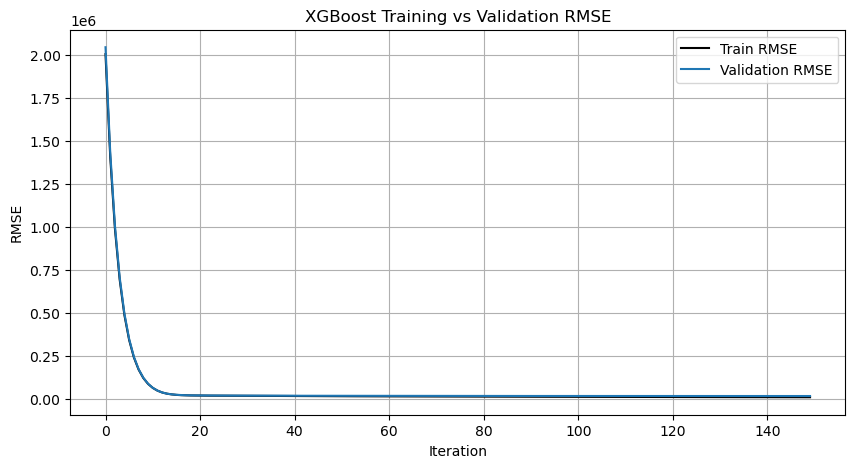

In [91]:
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# Define the model (PUT eval_metric HERE)
XGB = XGBRegressor(
    n_estimators=150,
    max_depth=5,
    random_state=7,
    eval_metric="rmse"
)

# Fit the model
XGB.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# Retrieve evaluation results
results = XGB.evals_result()
train_rmse = results['validation_0']['rmse']
val_rmse = results['validation_1']['rmse']

# Plot RMSE
plt.figure(figsize=(10,5))
plt.plot(train_rmse, label='Train RMSE',color='black')
plt.plot(val_rmse, label='Validation RMSE')
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.title('XGBoost Training vs Validation RMSE')
plt.legend()
plt.grid(True)
plt.show()


Train R² score: 0.9999908236740278
Validation R² score: 0.9999710539906691


<Figure size 600x400 with 0 Axes>

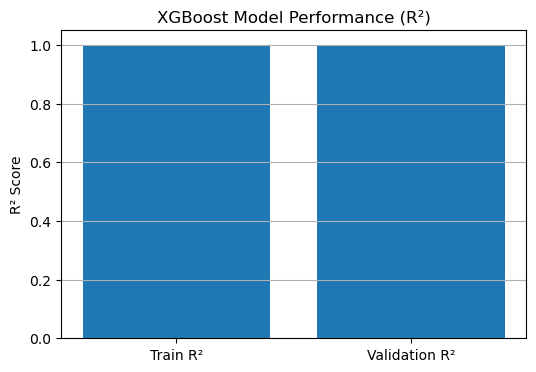

In [90]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Define the model (no eval_metric needed for score)
XGB = XGBRegressor(
    n_estimators=150,
    max_depth=5,
    random_state=7
)

# Fit the model
XGB.fit(X_train, y_train)

# Predictions
y_train_pred = XGB.predict(X_train)
y_val_pred = XGB.predict(X_val)

# Compute R² scores
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)

print("Train R² score:", train_r2)
print("Validation R² score:", val_r2)


plt.figure(figsize=(6,4))
plt.bar(['Train R²', 'Validation R²'], [train_r2, val_r2])
plt.ylabel('R² Score')
plt.title('XGBoost Model Performance (R²)')
plt.grid(axis='y')
plt.show()
